In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats



Generating one Normal Bragg curve


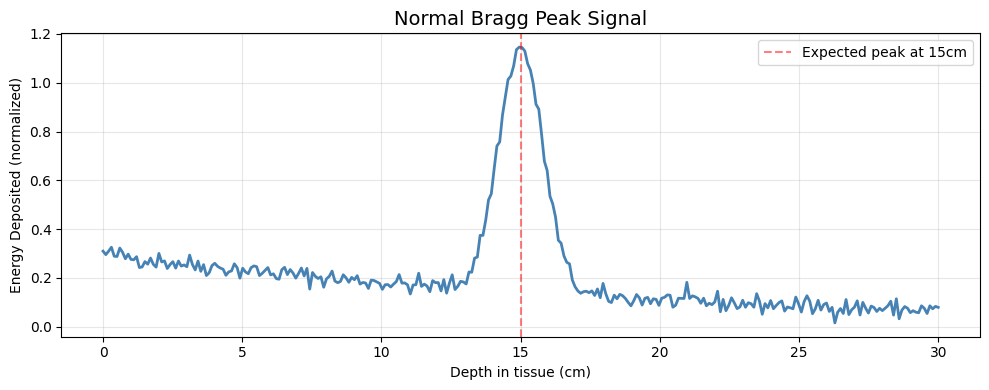

Signal shape: (300,)
Peak value: 1.146
Peak location: 14.95 cm


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define depth axis
# Think of this as ruler from 0 to 30 cm into the body
depth = np.linspace(0, 30, 300)

# Step 2: Define a function that creates one Bragg curve
def generate_bragg_curve(
    peak_position=15.0,   # where the peak appears (cm)
    peak_width=0.8,       # how wide/sharp the peak is
    amplitude=1.0,        # how tall the peak is
    noise_level=0.02      # how much random detector noise to add
):
    # Entrance dose: beam slowly entering the body (flat-ish region)
    entrance = 0.3 * np.exp(-0.05 * depth)
    
    # Bragg peak: sharp rise at the end (Gaussian shape)
    peak = amplitude * np.exp(-((depth - peak_position)**2) / (2 * peak_width**2))
    
    # Noise: real detectors are never perfect
    noise = np.random.normal(0, noise_level, size=len(depth))
    
    # Final signal = entrance + peak + noise
    signal = entrance + peak + noise
    
    return signal

# Step 3: Generate one normal curve
np.random.seed(42)  # makes results reproducible
normal_signal = generate_bragg_curve()

# Step 4: Plot it
plt.figure(figsize=(10, 4))
plt.plot(depth, normal_signal, color='steelblue', linewidth=2)
plt.title('Normal Bragg Peak Signal', fontsize=14)
plt.xlabel('Depth in tissue (cm)')
plt.ylabel('Energy Deposited (normalized)')
plt.axvline(x=15, color='red', linestyle='--', alpha=0.5, label='Expected peak at 15cm')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Signal shape:", normal_signal.shape)
print("Peak value:", round(normal_signal.max(), 4))
print("Peak location:", round(depth[normal_signal.argmax()], 2), "cm")

Generating all 4 Anomaly Types

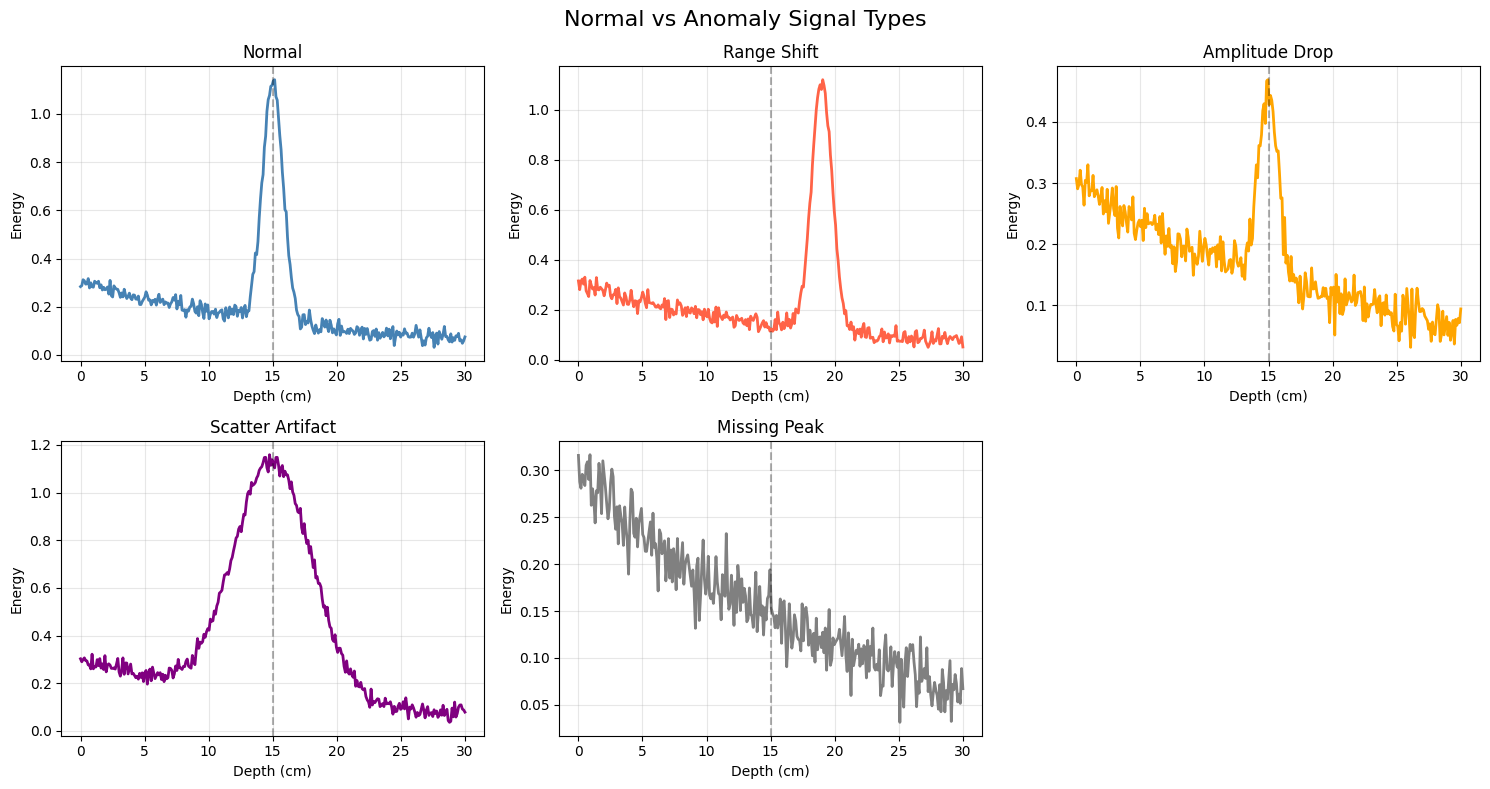

In [3]:
def generate_anomaly(anomaly_type):
    
    if anomaly_type == 'range_shift':
        # Peak appears 4cm too deep — beam overshot the tumor
        return generate_bragg_curve(peak_position=19.0)
    
    elif anomaly_type == 'amplitude_drop':
        # Peak is too weak — beam delivery failed partially
        return generate_bragg_curve(amplitude=0.3)
    
    elif anomaly_type == 'scatter_artifact':
        # Peak is very wide/blurry — beam scattered inside body
        return generate_bragg_curve(peak_width=3.0)
    
    elif anomaly_type == 'missing_peak':
        # No peak at all — complete delivery failure
        entrance_only = 0.3 * np.exp(-0.05 * depth)
        noise = np.random.normal(0, 0.02, size=len(depth))
        return entrance_only + noise

# Plot all types together
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Normal vs Anomaly Signal Types', fontsize=16)

types = {
    'Normal': generate_bragg_curve(),
    'Range Shift': generate_anomaly('range_shift'),
    'Amplitude Drop': generate_anomaly('amplitude_drop'),
    'Scatter Artifact': generate_anomaly('scatter_artifact'),
    'Missing Peak': generate_anomaly('missing_peak'),
}

colors = ['steelblue', 'tomato', 'orange', 'purple', 'gray']

for ax, (title, signal), color in zip(axes.flat, types.items(), colors):
    ax.plot(depth, signal, color=color, linewidth=2)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Depth (cm)')
    ax.set_ylabel('Energy')
    ax.axvline(x=15, color='black', linestyle='--', alpha=0.3)
    ax.grid(True, alpha=0.3)

axes[1, 2].axis('off')  # hide empty 6th subplot
plt.tight_layout()
plt.show()

This figure shows different types of proton beam energy deposition signals, known as Bragg curves, which represent how energy is delivered at different depths. In the normal case, the curve has a sharp peak around 15 cm, indicating that the maximum energy is deposited at the expected location, which is ideal for targeting a tumor. In the range shift case, the peak is shifted deeper, meaning the beam is depositing energy beyond the intended position, which can harm healthy tissue. In the amplitude drop case, the peak occurs at the correct depth but with reduced height, indicating that the beam intensity is lower and may not deliver sufficient dose to the target. The scatter artifact shows a wider and less sharp peak, suggesting that the beam is spreading out and losing precision. Finally, in the missing peak case, there is no clear peak at all, indicating a failure in beam delivery. These variations are important for anomaly detection, as a model can be trained to recognize the normal pattern and identify deviations that represent potential errors in proton therapy dose delivery.

Generating Full Dataset

In [4]:
import pandas as pd

# How many signals to generate
N_NORMAL = 5000
N_EACH_ANOMALY = 250   # x4 anomaly types = 1000 total anomalies

all_signals = []
all_labels = []

# Generate normal signals
for _ in range(N_NORMAL):
    # Slight random variation in peak position (±1cm) and width
    signal = generate_bragg_curve(
        peak_position=np.random.uniform(14, 16),
        peak_width=np.random.uniform(0.6, 1.0),
        amplitude=np.random.uniform(0.9, 1.1)
    )
    all_signals.append(signal)
    all_labels.append('normal')

# Generate anomaly signals
for _ in range(N_EACH_ANOMALY):
    all_signals.append(generate_anomaly('range_shift'))
    all_labels.append('range_shift')
    
    all_signals.append(generate_anomaly('amplitude_drop'))
    all_labels.append('amplitude_drop')
    
    all_signals.append(generate_anomaly('scatter_artifact'))
    all_labels.append('scatter_artifact')
    
    all_signals.append(generate_anomaly('missing_peak'))
    all_labels.append('missing_peak')

# Convert to numpy arrays
X = np.array(all_signals)   # shape: (6000, 300)
y = np.array(all_labels)    # shape: (6000,)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)
print("\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count} signals")

Dataset shape: (6000, 300)
Labels shape: (6000,)

Class distribution:
  amplitude_drop: 250 signals
  missing_peak: 250 signals
  normal: 5000 signals
  range_shift: 250 signals
  scatter_artifact: 250 signals


Saving dataset


In [5]:
# Save signals as numpy file (efficient for arrays)
np.save('bragg_signals.npy', X)
np.save('bragg_labels.npy', y)

# Also save as CSV for easy inspection
df = pd.DataFrame(X)
df.columns = [f'depth_{i}' for i in range(300)]
df['label'] = y
df.to_csv('bragg_dataset.csv', index=False)

print("✅ Dataset saved successfully!")
print(f"   bragg_signals.npy → {X.nbytes / 1024:.1f} KB")
print(f"   bragg_dataset.csv → open this in Excel to see it")

✅ Dataset saved successfully!
   bragg_signals.npy → 14062.5 KB
   bragg_dataset.csv → open this in Excel to see it


In [6]:
print("Min signal value:", X.min().round(4))
print("Max signal value:", X.max().round(4))
print("Any negative values?", (X < 0).any())

Min signal value: -0.0176
Max signal value: 1.3045
Any negative values? True
